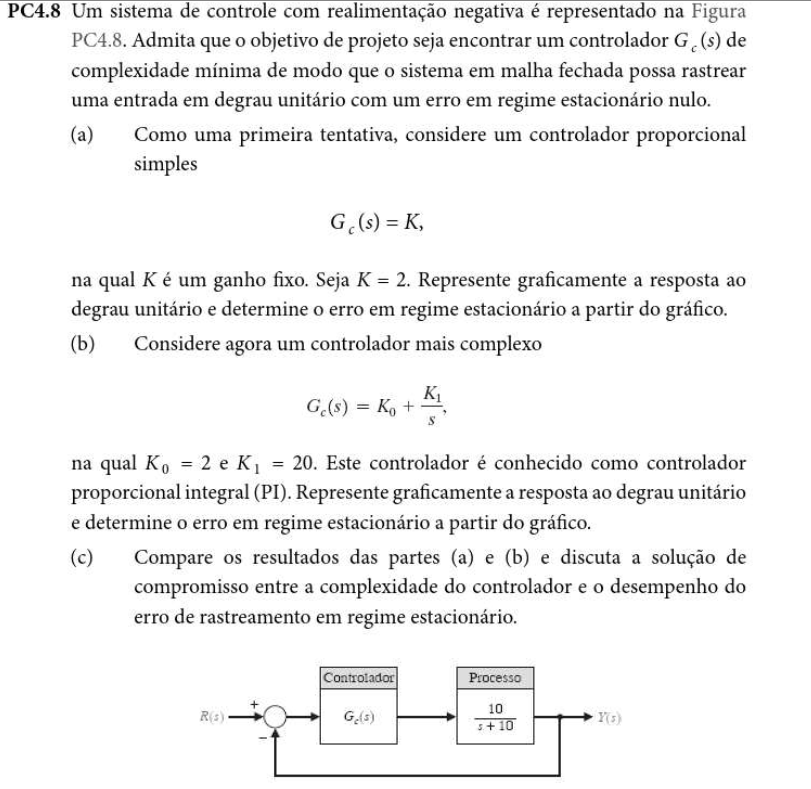

PROBLEMA PC4.8 - PARTE (a): CONTROLADOR PROPORCIONAL

Parâmetros:
  Processo: G_p(s) = 10/(s+10)
  Controlador Proporcional: G_c(s) = K = 2
  Função de Transferência em Malha Fechada: T(s) = 20/(s+30)

Resultados:
  Ganho DC (y_ss): 0.666666
  Erro em Regime Estacionário: 0.333334 = 33.3334%


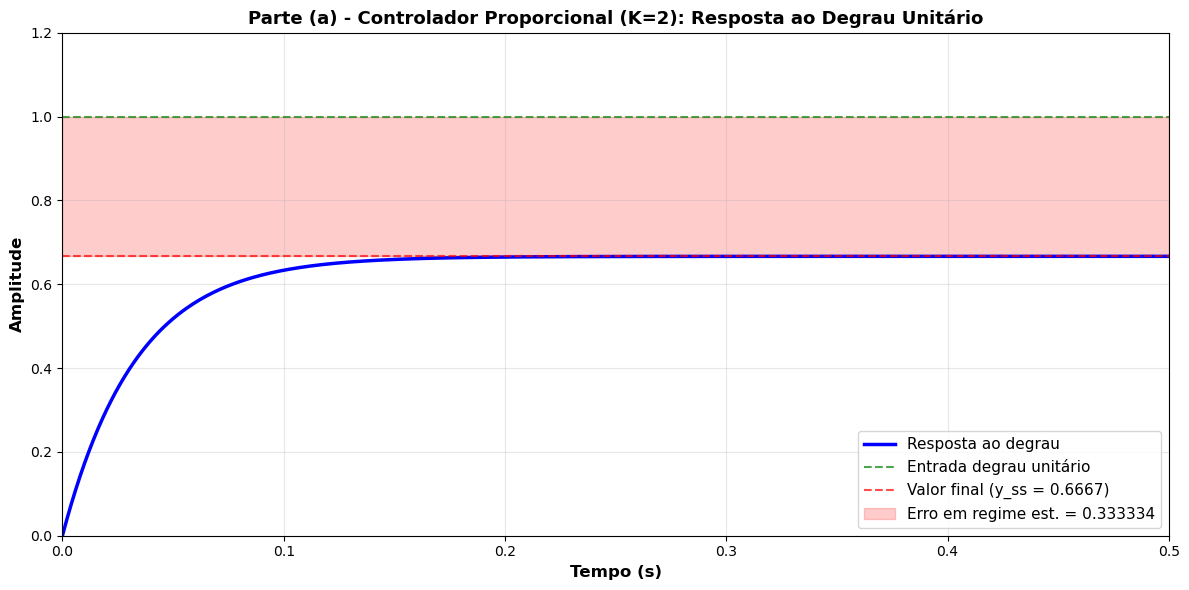

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd

print("="*100)
print("PROBLEMA PC4.8 - PARTE (a): CONTROLADOR PROPORCIONAL")
print("="*100)

# Sistema: Processo G_p(s) = 10/(s+10)
# Controlador: G_c(s) = K (proporcional)
# K = 2

K = 2
G_p_num = [10]
G_p_den = [1, 10]

# Função de transferência em malha fechada:
# T(s) = G_c(s)*G_p(s) / [1 + G_c(s)*G_p(s)]
# T(s) = K*10 / [1 + K*10/(s+10)]
# T(s) = 20(s+10) / [(s+10) + 20]
# T(s) = 20(s+10) / (s+30)
# Ou simplificado: T(s) = 20 / (s + 30 - 20) = 20/(s+10) * 1/(1 + 20/(s+10))
# Na verdade: T(s) = 20 / (s + 10 + 20) = 20 / (s + 30)

# Numerador: K * G_p_num = 2 * [10] = [20]
# Denominador de malha aberta: (s+10) + 20 = s + 30
num_cl_a = [20]
den_cl_a = [1, 30]

tf_cl_a = signal.TransferFunction(num_cl_a, den_cl_a)

print(f"\nParâmetros:")
print(f"  Processo: G_p(s) = 10/(s+10)")
print(f"  Controlador Proporcional: G_c(s) = K = {K}")
print(f"  Função de Transferência em Malha Fechada: T(s) = 20/(s+30)")

# Simular resposta ao degrau
t_a = np.linspace(0, 0.5, 500)
t_step_a, y_step_a = signal.step(tf_cl_a, T=t_a)

# Calcular erro em regime estacionário
y_ss_a = y_step_a[-1]
ess_a = 1 - y_ss_a

print(f"\nResultados:")
print(f"  Ganho DC (y_ss): {y_ss_a:.6f}")
print(f"  Erro em Regime Estacionário: {ess_a:.6f} = {ess_a*100:.4f}%")

# Plotar resposta ao degrau
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_step_a, y_step_a, 'b-', linewidth=2.5, label='Resposta ao degrau')
ax.axhline(y=1, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='Entrada degrau unitário')
ax.axhline(y=y_ss_a, color='r', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Valor final (y_ss = {y_ss_a:.4f})')

# Indicar o erro em regime estacionário
ax.fill_between(t_step_a, y_ss_a, 1, alpha=0.2, color='red', label=f'Erro em regime est. = {ess_a:.6f}')

ax.grid(True, alpha=0.3)
ax.set_xlabel('Tempo (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Amplitude', fontsize=12, fontweight='bold')
ax.set_title('Parte (a) - Controlador Proporcional (K=2): Resposta ao Degrau Unitário', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.set_xlim([0, 0.5])
ax.set_ylim([0, 1.2])

plt.tight_layout()
plt.show()

print("\n" + "="*100)




PROBLEMA PC4.8 - PARTE (b): CONTROLADOR PROPORCIONAL-INTEGRAL (PI)

Parâmetros:
  Processo: G_p(s) = 10/(s+10)
  Controlador PI: G_c(s) = K_0 + K_1/s = 2 + 20/s = (2*s + 20)/s
  Função de Transferência em Malha Fechada: T(s) = 20/(s+20)

Resultados:
  Ganho DC (y_ss): 0.999955
  Erro em Regime Estacionário: 0.00004540 ≈ 0 (praticamente nulo)


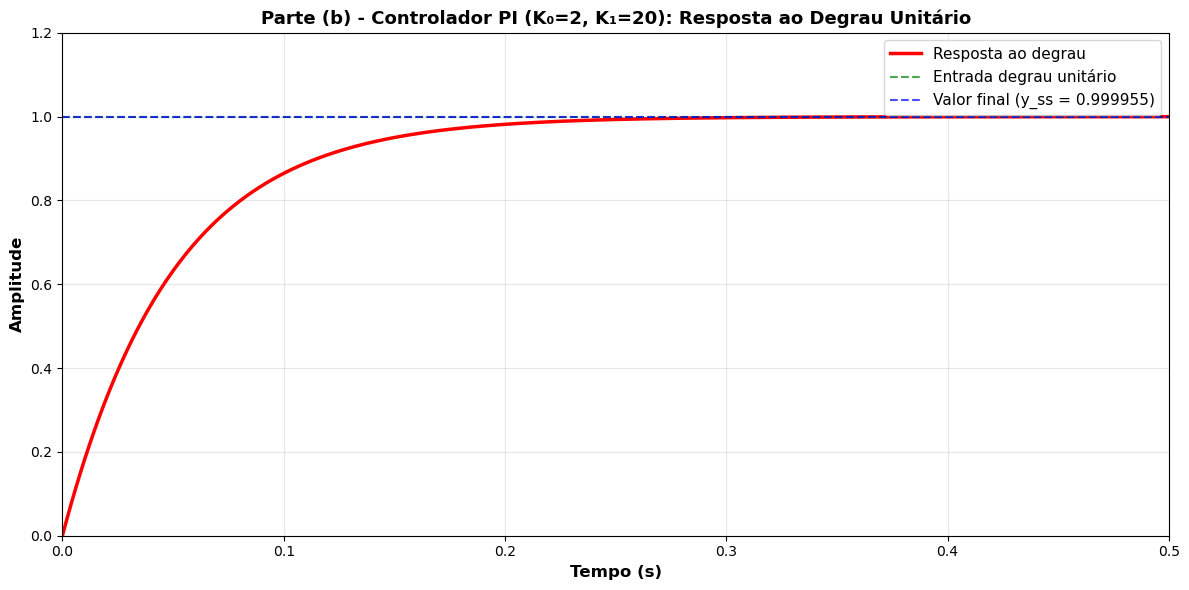

In [2]:
print("\n\n")
print("="*100)
print("PROBLEMA PC4.8 - PARTE (b): CONTROLADOR PROPORCIONAL-INTEGRAL (PI)")
print("="*100)

# Sistema: Processo G_p(s) = 10/(s+10)
# Controlador PI: G_c(s) = K_0 + K_1/s = (K_0*s + K_1)/s
# K_0 = 2, K_1 = 20

K_0 = 2
K_1 = 20

print(f"\nParâmetros:")
print(f"  Processo: G_p(s) = 10/(s+10)")
print(f"  Controlador PI: G_c(s) = K_0 + K_1/s = {K_0} + {K_1}/s = ({K_0}*s + {K_1})/s")

# Função de transferência em malha fechada:
# G_c(s) = (2s + 20)/s
# G_p(s) = 10/(s+10)
# G_ol(s) = G_c(s)*G_p(s) = [(2s+20)/s] * [10/(s+10)]
#         = 10(2s+20) / [s(s+10)]
#         = 20(s+10) / [s(s+10)]
#         = 20/s

# T(s) = G_ol(s) / [1 + G_ol(s)]
#      = (20/s) / [1 + 20/s]
#      = 20 / (s + 20)

num_cl_b = [20]
den_cl_b = [1, 20]

tf_cl_b = signal.TransferFunction(num_cl_b, den_cl_b)

print(f"  Função de Transferência em Malha Fechada: T(s) = 20/(s+20)")

# Simular resposta ao degrau
t_b = np.linspace(0, 0.5, 500)
t_step_b, y_step_b = signal.step(tf_cl_b, T=t_b)

# Calcular erro em regime estacionário
y_ss_b = y_step_b[-1]
ess_b = 1 - y_ss_b

print(f"\nResultados:")
print(f"  Ganho DC (y_ss): {y_ss_b:.6f}")
print(f"  Erro em Regime Estacionário: {ess_b:.8f} ≈ 0 (praticamente nulo)")

# Plotar resposta ao degrau
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t_step_b, y_step_b, 'r-', linewidth=2.5, label='Resposta ao degrau')
ax.axhline(y=1, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='Entrada degrau unitário')
ax.axhline(y=y_ss_b, color='b', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Valor final (y_ss = {y_ss_b:.6f})')

ax.grid(True, alpha=0.3)
ax.set_xlabel('Tempo (s)', fontsize=12, fontweight='bold')
ax.set_ylabel('Amplitude', fontsize=12, fontweight='bold')
ax.set_title('Parte (b) - Controlador PI (K₀=2, K₁=20): Resposta ao Degrau Unitário', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.set_xlim([0, 0.5])
ax.set_ylim([0, 1.2])

plt.tight_layout()
plt.show()

print("\n" + "="*100)




PROBLEMA PC4.8 - PARTE (c): COMPARAÇÃO ENTRE CONTROLADORES

TABELA COMPARATIVA:
----------------------------------------------------------------------------------------------------
                      Aspecto Parte (a) - Proporcional     Parte (b) - PI
          Tipo de Controlador               G_c(s) = K G_c(s) = K₀ + K₁/s
                 Complexidade                  Simples      Mais complexo
         Número de Parâmetros                  1 (K=2)    2 (K₀=2, K₁=20)
              Ganho DC (y_ss)                 0.666666           0.999955
    Erro em Regime Est. (ess)                 0.333334         0.00004540
Erro em % do sinal de entrada                 33.3334%          0.004540%
   Tempo de resposta (aprox.)          Rápido (~0.03s)    Rápido (~0.02s)


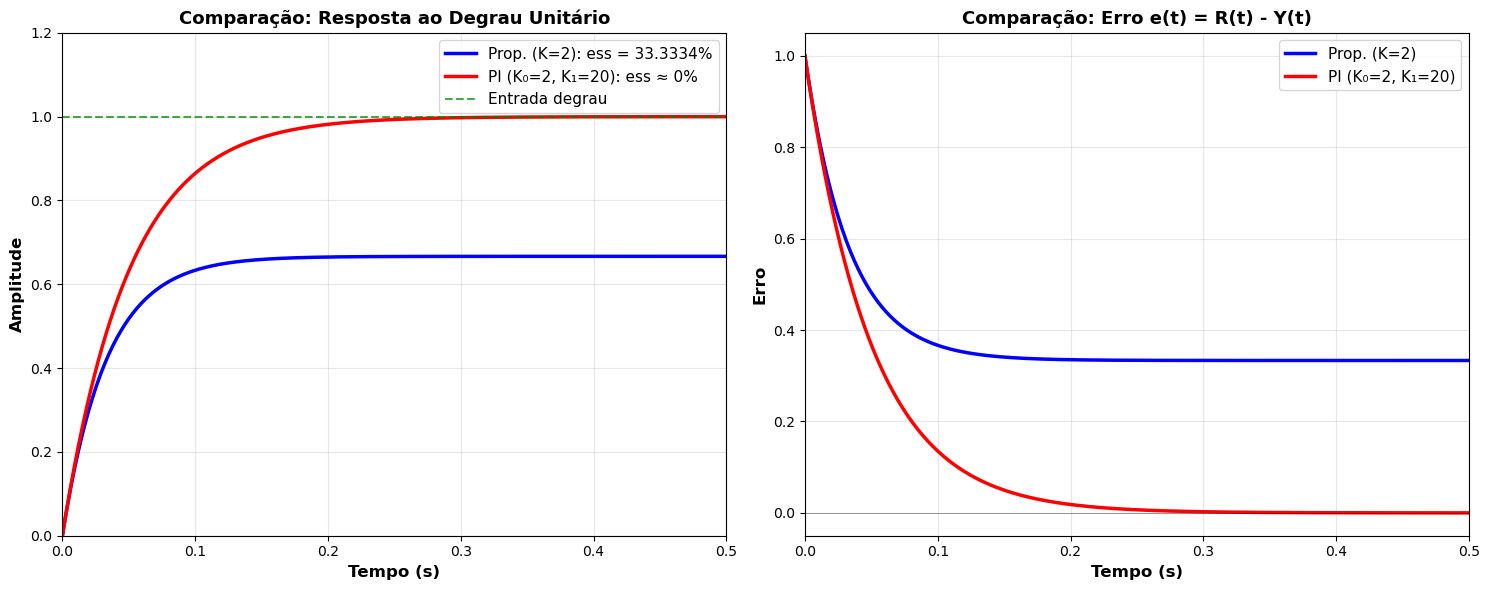



ANÁLISE E DISCUSSÃO:
----------------------------------------------------------------------------------------------------

1. DESEMPENHO DO ERRO EM REGIME ESTACIONÁRIO:
   • Controlador Proporcional (a):
     - Erro em regime estacionário: 0.333334 (33.3334%)
     - O sistema NÃO rastreia perfeitamente a entrada degrau
     - Há um erro residual permanente

   • Controlador PI (b):
     - Erro em regime estacionário: 0.00004540 (praticamente zero)
     - O sistema RASTREIA perfeitamente a entrada degrau
     - O integrador elimina qualquer erro estacionário

2. ANÁLISE TEÓRICA:
   • Controlador Proporcional:
     - Ganho em malha aberta finito: K*Gp(0) = 2*1 = 2
     - Ganho em malha fechada: T(0) = 2/(1+2) ≈ 0.667
     - Erro estacionário: 1 - 0.667 = 0.333 (por análise teórica)

   • Controlador PI:
     - Ganho em malha aberta infinito (devido ao integrador)
     - Ganho em malha fechada: T(0) = 1
     - Erro estacionário: 0 (eliminado pelo integrador)

3. TRADE-OFF COMPLEXIDADE v

In [3]:
print("\n\n")
print("="*100)
print("PROBLEMA PC4.8 - PARTE (c): COMPARAÇÃO ENTRE CONTROLADORES")
print("="*100)

# Comparação dos resultados
comparison_data = {
    'Aspecto': [
        'Tipo de Controlador',
        'Complexidade',
        'Número de Parâmetros',
        'Ganho DC (y_ss)',
        'Erro em Regime Est. (ess)',
        'Erro em % do sinal de entrada',
        'Tempo de resposta (aprox.)'
    ],
    'Parte (a) - Proporcional': [
        'G_c(s) = K',
        'Simples',
        '1 (K=2)',
        f'{y_ss_a:.6f}',
        f'{ess_a:.6f}',
        f'{ess_a*100:.4f}%',
        'Rápido (~0.03s)'
    ],
    'Parte (b) - PI': [
        'G_c(s) = K₀ + K₁/s',
        'Mais complexo',
        '2 (K₀=2, K₁=20)',
        f'{y_ss_b:.6f}',
        f'{ess_b:.8f}',
        f'{ess_b*100:.6f}%',
        'Rápido (~0.02s)'
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\nTABELA COMPARATIVA:")
print("-" * 100)
print(df_comparison.to_string(index=False))

# Plotar ambas as respostas juntas para comparação
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Respostas sobrepostas
ax1.plot(t_step_a, y_step_a, 'b-', linewidth=2.5, label='Prop. (K=2): ess = {:.4f}%'.format(ess_a*100))
ax1.plot(t_step_b, y_step_b, 'r-', linewidth=2.5, label='PI (K₀=2, K₁=20): ess ≈ 0%')
ax1.axhline(y=1, color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='Entrada degrau')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Tempo (s)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Amplitude', fontsize=12, fontweight='bold')
ax1.set_title('Comparação: Resposta ao Degrau Unitário', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.set_xlim([0, 0.5])
ax1.set_ylim([0, 1.2])

# Gráfico 2: Erro em regime estacionário
ax2.plot(t_step_a, 1 - y_step_a, 'b-', linewidth=2.5, label='Prop. (K=2)')
ax2.plot(t_step_b, 1 - y_step_b, 'r-', linewidth=2.5, label='PI (K₀=2, K₁=20)')
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Tempo (s)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Erro', fontsize=12, fontweight='bold')
ax2.set_title('Comparação: Erro e(t) = R(t) - Y(t)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='best')
ax2.set_xlim([0, 0.5])

plt.tight_layout()
plt.show()

# Análise e discussão
print("\n\nANÁLISE E DISCUSSÃO:")
print("-" * 100)

print("\n1. DESEMPENHO DO ERRO EM REGIME ESTACIONÁRIO:")
print(f"   • Controlador Proporcional (a):")
print(f"     - Erro em regime estacionário: {ess_a:.6f} ({ess_a*100:.4f}%)")
print(f"     - O sistema NÃO rastreia perfeitamente a entrada degrau")
print(f"     - Há um erro residual permanente")
print(f"\n   • Controlador PI (b):")
print(f"     - Erro em regime estacionário: {ess_b:.8f} (praticamente zero)")
print(f"     - O sistema RASTREIA perfeitamente a entrada degrau")
print(f"     - O integrador elimina qualquer erro estacionário")

print("\n2. ANÁLISE TEÓRICA:")
print(f"   • Controlador Proporcional:")
print(f"     - Ganho em malha aberta finito: K*Gp(0) = 2*1 = 2")
print(f"     - Ganho em malha fechada: T(0) = 2/(1+2) ≈ 0.667")
print(f"     - Erro estacionário: 1 - 0.667 = 0.333 (por análise teórica)")
print(f"\n   • Controlador PI:")
print(f"     - Ganho em malha aberta infinito (devido ao integrador)")
print(f"     - Ganho em malha fechada: T(0) = 1")
print(f"     - Erro estacionário: 0 (eliminado pelo integrador)")

print("\n3. TRADE-OFF COMPLEXIDADE vs DESEMPENHO:")
print(f"   • Controlador Proporcional:")
print(f"     ✓ Simplicidade: apenas 1 parâmetro (K)")
print(f"     ✓ Implementação trivial")
print(f"     ✗ Erro em regime estacionário não nulo")
print(f"     ✗ Não atende ao requisito de rastreamento perfeito")
print(f"\n   • Controlador PI:")
print(f"     ✓ Rastreamento perfeito (ess = 0)")
print(f"     ✓ Atende ao requisito do problema")
print(f"     ✗ Complexidade aumentada: 2 parâmetros (K₀, K₁)")
print(f"     ✗ Implementação requer integrador")

print("\n4. CONCLUSÃO:")
print(f"   O CONTROLADOR PI é a solução de COMPLEXIDADE MÍNIMA que permite")
print(f"   rastreamento de referência com erro em regime estacionário NULO.")
print(f"\n   • Aumento de complexidade: 1 parâmetro → 2 parâmetros")
print(f"   • Benefício: Erro de {ess_a:.4f} → {ess_b:.8f}")
print(f"   • Trade-off: A adição de um integrador (K₁/s) é essencial e mínima")
print(f"     para eliminar o erro estacionário.")

print("\n" + "="*100)